# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:
# importar librerías
import pandas  as pd               # LECTURA, MANEJO Y TRANSFORMACIÓN DE DATAFRAMES.
import numpy   as np               # FUNCIONES MATEMÁTICAS RELEVANTES.
import matplotlib.pyplot as plt    # GRÁFICOS.
import seaborn as sns              # GRÁFICOS PRETTY.
from scipy.stats import ttest_ind  # Promedios (2 Grupos)
from scipy.stats import levene     # Varianzas
from statsmodels.stats.proportion import proportions_ztest  # Proporciones% Binarios
from scipy.stats import chi2_contingency #Chi cuadrado (categórica)

#CONFIGURACIONES GLOBALES:
import warnings                                                #MANEJO DE WARNINGS - ADVERTENCIAS
warnings.simplefilter(action='ignore', category=FutureWarning) #QUITAR WARNINGS MOLESTOS
pd.set_option('display.max_columns', None)                     #ELIMINA LIMITES DE PANDAS PARA MOSTRAR COLUMNAS
pd.set_option('display.max_rows', None)                        #ELIMINA LIMITES DE PANDAS PARA MOSTRAR FILAS
pd.set_option('display.max_colwidth', None)

In [2]:
# cargar archivos
orders_raw = pd.read_csv('https://raw.githubusercontent.com/FithoGerardo/RappiPlus-Data-cleaning-and-analysis/refs/heads/main/data/rappiplus_orders_raw.csv')
catalog_raw = pd.read_csv('https://raw.githubusercontent.com/FithoGerardo/RappiPlus-Data-cleaning-and-analysis/refs/heads/main/data/rappiplus_catalog.csv')
marketing_raw = pd.read_csv('https://raw.githubusercontent.com/FithoGerardo/RappiPlus-Data-cleaning-and-analysis/refs/heads/main/data/rappiplus_marketing_spend.csv')

In [3]:
# cargar archivos
# orders_raw = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
# catalog_raw = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
# marketing_raw = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

### Crear copias para trabajar con ellas.

In [4]:
# Copias
ord = orders_raw.copy()
ctl = catalog_raw.copy()
mkt = marketing_raw.copy()

In [5]:
# explorar datasets
display(ord.head(2))
display(ord.columns)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86


Index(['id_pedido', 'id_usuario', 'fecha_hora_pedido', 'pais', 'dispositivo',
       'fuente_referencia', 'nombre_producto', 'categoria_producto',
       'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total'],
      dtype='object')

In [6]:
display(ctl.head(2))
display(ctl.columns)

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd


Index(['nombre_producto', 'categoria_producto', 'costo_unitario', 'proveedor'], dtype='object')

In [7]:
display(mkt.head(2))
display(mkt.columns)

,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34


Index(['fecha', 'pais', 'id_campaña', 'canal', 'gasto'], dtype='object')

---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas

---

In [8]:
# Revisar duplicados
dup_ord = ord.duplicated().sum()
dup_ctl = ctl.duplicated().sum()
dup_mkt = mkt.duplicated().sum()
print(f"Filas duplicadas: {dup_ord}")
print(f"Filas duplicadas: {dup_ctl}")
print(f"Filas duplicadas: {dup_mkt}")

Filas duplicadas: 100
Filas duplicadas: 0
Filas duplicadas: 0


In [9]:
# Revisar duplicados por pedido
ord[ord['id_pedido'].duplicated(keep=False)]\
.sort_values('id_pedido').head(4)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
25023,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2.0,221.34,0.0,442.67
10082,order_10082,user_690,2025-02-17,Argentina,desktop,social,Sneakers-Urban-42,Moda,2.0,221.34,0.0,442.67
25037,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1.0,170.10,10.0,160.10
10709,order_10709,user_6783,2025-02-16,Colombia,mobile,organic,Jacket-Winter-M,Moda,1.0,170.10,10.0,160.10


In [10]:
# eliminar duplicados
ord = ord.drop_duplicates(subset='id_pedido', keep='first')

# verificar eliminación de duplicados
dup_ord = ord.duplicated().sum()
print(f"Filas duplicadas: {dup_ord}")

Filas duplicadas: 0


In [11]:
for df in [ord, ctl, mkt]:
    print("\n", df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25000 non-null  object 
 1   id_usuario          25000 non-null  object 
 2   fecha_hora_pedido   25000 non-null  object 
 3   pais                24700 non-null  object 
 4   dispositivo         24980 non-null  object 
 5   fuente_referencia   24970 non-null  object 
 6   nombre_producto     24970 non-null  object 
 7   categoria_producto  24920 non-null  object 
 8   cantidad            24950 non-null  float64
 9   precio_unitario     24950 non-null  float64
 10  monto_descuento     24950 non-null  float64
 11  monto_total         25000 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.5+ MB

 None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
--

In [12]:
display(ord.isnull().sum()) # cantidad valores nulos
display(ord.isna().mean()*100) # proporción valores nulos
display(ctl.isnull().sum())
display(ctl.isna().mean()*100)
display(mkt.isnull().sum())
display(mkt.isna().mean()*100)
print()

print()
print("Valores nulos en orders?", ord.isnull().values.any())
print("Valores nulos en catalog?", ctl.isnull().values.any())
print("Valores nulos en marketing?", mkt.isnull().values.any())

,0
id_pedido,0
id_usuario,0
fecha_hora_pedido,0
pais,300
dispositivo,20
fuente_referencia,30
nombre_producto,30
categoria_producto,80
cantidad,50
precio_unitario,50


,0
id_pedido,0.00
id_usuario,0.00
fecha_hora_pedido,0.00
pais,1.20
dispositivo,0.08
fuente_referencia,0.12
nombre_producto,0.12
categoria_producto,0.32
cantidad,0.20
precio_unitario,0.20


,0
nombre_producto,0
categoria_producto,0
costo_unitario,0
proveedor,0


,0
nombre_producto,0.0
categoria_producto,0.0
costo_unitario,0.0
proveedor,0.0


,0
fecha,0
pais,0
id_campaña,0
canal,101
gasto,0


,0
fecha,0.000000
pais,0.000000
id_campaña,0.000000
canal,6.234568
gasto,0.000000




Valores nulos en orders? True
Valores nulos en catalog? False
Valores nulos en marketing? True


Cantidad y porcentaje (\%) de nulos.

Orders:

* pais	300 | 1.195219
* dispositivo	20 | 0.079681
* fuente_referencia	30 | 0.119522
* nombre_producto	30 | 0.119522
* categoria_producto	80 | 0.318725
* cantidad	50 | 0.199203
* precio_unitario	50 | 0.199203
* monto_descuento	50 | 0.199203

Marketing:

* canal	101 | 6.234568
---

- orders:
- - fecha_hora_pedido object to date
- - cantidad float to int
- - redondear a dos decimales
- - pais a estandarizar
- marketing:
- - date object to date

Se asociará 'categoria_producto' a 'nombre_producto'.

'pais', 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto' a 'unknown'

'monto_descuento' a '0'

Se eliminarán registros de 'cantidad', 'precio_unitario', 'monto_descuento' como NaN

Se buscaron negativos y cambiaron a positivos por error de registro.

Búsqueda de outliers en 'cantidad' con IQR. Registros eliminados.

Cambiar nombre 'fecha_hora_pedido' a 'fecha_pedido'.

Cambiar nombre a 'id_campana' y asociar 'id_campaña' a 'canal'.


In [13]:
# convertir object a date
ord['fecha_hora_pedido'] = pd.to_datetime(ord['fecha_hora_pedido'])
mkt['fecha'] = pd.to_datetime(mkt['fecha'])
for df in [ord, mkt]:
    print("\n", df.info())
    display(df.head(2))

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 24999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           25000 non-null  object        
 1   id_usuario          25000 non-null  object        
 2   fecha_hora_pedido   25000 non-null  datetime64[ns]
 3   pais                24700 non-null  object        
 4   dispositivo         24980 non-null  object        
 5   fuente_referencia   24970 non-null  object        
 6   nombre_producto     24970 non-null  object        
 7   categoria_producto  24920 non-null  object        
 8   cantidad            24950 non-null  float64       
 9   precio_unitario     24950 non-null  float64       
 10  monto_descuento     24950 non-null  float64       
 11  monto_total         25000 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(7)
memory usage: 2.5+ MB

 None


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campaña  1620 non-null   object        
 3   canal       1519 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB

 None


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34


In [14]:
# estandarizar países
display(ord['pais'].value_counts())

,count
pais,
Colombia,7481
Mexico,7478
Argentina,7259
mexico,863
colombia,823
argentina,796


In [15]:
ord['pais'] = ord['pais'].str.capitalize()
display(ord['pais'].value_counts())

,count
pais,
Mexico,8341
Colombia,8304
Argentina,8055


In [16]:
display(ord[ord[['cantidad', 'monto_descuento', 'precio_unitario']].isna().any(axis=1)].head(10))

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
74,order_74,user_6172,2025-01-15,Argentina,desktop,organic,Sneakers-Urban-42,NaN,NaN,NaN,NaN,595.85
75,order_75,user_6588,2025-06-19,Colombia,mobile,organic,Sneakers-Urban-42,NaN,NaN,NaN,NaN,458.15
76,order_76,user_3193,2025-03-17,Argentina,mobile,paid_search,Laptop-Gaming-16GB,NaN,NaN,NaN,NaN,319.75
77,order_77,user_775,2025-06-24,Argentina,desktop,social,Vacuum-Pro-Black,NaN,NaN,NaN,NaN,227.55
78,order_78,user_2702,2025-03-19,Argentina,desktop,paid_search,Phone-Pro-128GB,NaN,NaN,NaN,NaN,432.39
79,order_79,user_6438,2025-03-22,Colombia,desktop,paid_search,Sneakers-Urban-42,NaN,NaN,NaN,NaN,527.15
80,order_80,user_6790,2025-01-03,Mexico,desktop,organic,Vacuum-Pro-Black,NaN,NaN,NaN,NaN,711.18
81,order_81,user_232,2025-05-16,Mexico,mobile,paid_search,Tablet-Standard-64GB,NaN,NaN,NaN,NaN,41.08
82,order_82,user_5665,2025-02-07,Colombia,mobile,paid_search,Sneakers-Urban-42,NaN,NaN,NaN,NaN,431.55
83,order_83,user_5225,2025-04-25,Argentina,mobile,organic,Sneakers-Urban-42,NaN,NaN,NaN,NaN,279.35


In [17]:
# verificar usuarios con más de un país
usuarios_multipaís = (
    ord.groupby('id_usuario')['pais'].nunique().loc[lambda x: x > 1]
)

print(f"Usuarios con más de un país: {len(usuarios_multipaís)}")

Usuarios con más de un país: 0


In [18]:
# Obtener el país más frecuente de cada usuario
pais_usuario = (
    ord.dropna(subset=['pais']).groupby('id_usuario')['pais']
       .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

# Imputar nulos
ord['pais'] = ord['pais'].fillna(ord['id_usuario'].map(pais_usuario))

In [19]:
print("Registros de paises nulos")
display(ord['pais'].isnull().sum()) # cantidad valores nulos

Registros de paises nulos


np.int64(19)

In [20]:
# Relacionar categoría con nombre
ctl[['nombre_producto', 'categoria_producto']]
prod_cate = {
    'Laptop-Gaming-16GB' :	'Electrónica',
    'Phone-Pro-128GB'	: 'Electrónica',
    'Tablet-Standard-64GB'	: 'Electrónica',
    'Blender-XL-Red'	: 'Hogar',
    'Vacuum-Pro-Black'	: 'Hogar',
    'Sneakers-Urban-42'	: 'Moda',
    'Jacket-Winter-M'	: 'Moda'
}

ord['categoria_producto'] = (
    ord['categoria_producto'].fillna(ord['nombre_producto'].map(prod_cate))
)

In [21]:
# columnas categóricas a 'unknown'
cols_cat = ['pais', 'dispositivo', 'fuente_referencia', 'nombre_producto', 'categoria_producto']
ord[cols_cat] = ord[cols_cat].fillna('unknown')

In [22]:
# monto_descuento = 0
ord['monto_descuento'] = ord['monto_descuento'].fillna(0)

In [23]:
# eliminar filas NaN de cantidad y precio unitario
ord = ord.dropna(subset=['cantidad','precio_unitario'])
ord.reset_index(drop=True, inplace=True)

In [24]:
# convertir cantidad float a int
ord['cantidad'] = ord['cantidad'].astype(int)
display(ord.info())
display(ord.head(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24950 entries, 0 to 24949
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_pedido           24950 non-null  object        
 1   id_usuario          24950 non-null  object        
 2   fecha_hora_pedido   24950 non-null  datetime64[ns]
 3   pais                24950 non-null  object        
 4   dispositivo         24950 non-null  object        
 5   fuente_referencia   24950 non-null  object        
 6   nombre_producto     24950 non-null  object        
 7   categoria_producto  24950 non-null  object        
 8   cantidad            24950 non-null  int64         
 9   precio_unitario     24950 non-null  float64       
 10  monto_descuento     24950 non-null  float64       
 11  monto_total         24950 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(7)
memory usage: 2.3+ MB


None

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1,176.86,5.0,171.86


In [25]:
# redondear a dos decimales
ord[['precio_unitario', 'monto_descuento', 'monto_total']] = ord[['precio_unitario', 'monto_descuento', 'monto_total']].round(2)

In [26]:
# verificar cantidad de negativos
display((ord[
    ['precio_unitario', 'cantidad', 'monto_descuento', 'monto_total']] < 0).sum())

,0
precio_unitario,0
cantidad,4
monto_descuento,0
monto_total,4


In [27]:
# ver registros de negativos
display(ord[
    (ord[['precio_unitario', 'cantidad', 'monto_descuento', 'monto_total']] < 0).any(axis=1)
][['id_pedido', 'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']])

,id_pedido,cantidad,precio_unitario,monto_descuento,monto_total
216,order_266,-2,101.31,10.0,-192.62
217,order_267,-1,43.50,5.0,-38.50
218,order_268,-1,497.65,5.0,-492.65
219,order_269,-1,423.53,0.0,-423.53


In [28]:
# convertir a positivos para verificar cálculos
negativos = ord[
    (ord[['precio_unitario', 'cantidad', 'monto_descuento', 'monto_total']] < 0).any(axis=1)
][['id_pedido', 'cantidad', 'precio_unitario', 'monto_descuento', 'monto_total']]

negativos= negativos[['precio_unitario', 'cantidad', 'monto_descuento', 'monto_total']].abs()

negativos

,precio_unitario,cantidad,monto_descuento,monto_total
216,101.31,2,10.0,192.62
217,43.50,1,5.0,38.50
218,497.65,1,5.0,492.65
219,423.53,1,0.0,423.53


In [29]:
# verificar (precio_unitario * cantidad) - monto_descuento = monto_total
negativos['monto_calculado'] = (
    (negativos['precio_unitario'] * negativos['cantidad'])
    - negativos['monto_descuento']
)

# Verificar coincidencia con tolerancia
negativos['validacion'] = np.isclose( # validacion = True indica bien calculado
    negativos['monto_calculado'],
    negativos['monto_total'],
    atol=0.01  # tolerancia de 1 centavo
)

# Mostrar filas con inconsistencias
errores = negativos[~negativos['validacion']]

print(f"Registros incorrectos: {len(errores)}")
display(errores[['cantidad',
                'precio_unitario',
                'monto_descuento',
                'monto_total',
                'monto_calculado']])

display(negativos['validacion'].value_counts())

Registros incorrectos: 0


,cantidad,precio_unitario,monto_descuento,monto_total,monto_calculado


,count
validacion,
True,4


In [30]:
#aplicar cambios a ordenes
ord[['cantidad', 'monto_total']] = ord[['cantidad', 'monto_total']].abs()
display(ord[
    (ord['id_pedido'].isin(['order_266', 'order_267', 'order_268', 'order_269']))])

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
216,order_266,user_7011,2025-03-13,Colombia,desktop,paid_search,Phone-Pro-128GB,Electronica,2,101.31,10.0,192.62
217,order_267,user_1087,2025-05-07,Mexico,desktop,social,Phone-Pro-128GB,Electronica,1,43.50,5.0,38.50
218,order_268,user_84,2025-02-19,Colombia,desktop,organic,Phone-Pro-128GB,Electronica,1,497.65,5.0,492.65
219,order_269,user_3323,2025-05-25,Colombia,desktop,paid_search,Phone-Pro-128GB,Electronica,1,423.53,0.0,423.53


In [31]:
# verificar (precio_unitario * cantidad) - monto_descuento = monto_total
ord['monto_calculado'] = (
    (ord['precio_unitario'] * ord['cantidad'])
    - ord['monto_descuento']
)

# Verificar coincidencia con tolerancia
ord['validacion'] = np.isclose(
    ord['monto_calculado'],
    ord['monto_total'],
    atol=0.1   # tolerancia de 10 centavo
)

# Mostrar filas con inconsistencias
errores = ord[~ord['validacion']]

print(f"Registros incorrectos: {len(errores)}")
display(errores[['nombre_producto',
                'cantidad',
                'precio_unitario',
                'monto_descuento',
                'monto_total',
                'monto_calculado']])

display(negativos['validacion'].value_counts())

Registros incorrectos: 0


,nombre_producto,cantidad,precio_unitario,monto_descuento,monto_total,monto_calculado


,count
validacion,
True,4


In [32]:
ord[['nombre_producto',
     'cantidad',
     'precio_unitario',
     'monto_descuento',
     'monto_total',
     'monto_calculado',
     'validacion']].head(5)

,nombre_producto,cantidad,precio_unitario,monto_descuento,monto_total,monto_calculado,validacion
0,Jacket-Winter-M,2,332.69,0.0,665.37,665.38,True
1,Tablet-Standard-64GB,1,176.86,5.0,171.86,171.86,True
2,Blender-XL-Red,2,102.99,10.0,195.99,195.98,True
3,Tablet-Standard-64GB,1,257.87,15.0,242.87,242.87,True
4,Blender-XL-Red,1,336.28,0.0,336.28,336.28,True


In [33]:
# eliminar columnas creadas para cambio negativo a absoluto
ord.drop(columns=['monto_calculado', 'validacion'], inplace=True)


Columna: precio_unitario

Primer cuartil (Q1): 138.47
Tercer cuartil (Q3): 380.3775
Rango intercuartil (IQR): 241.9075

Límite inferior (lower_bound): -224.39124999999999
Límite superior (upper_bound): 743.23875



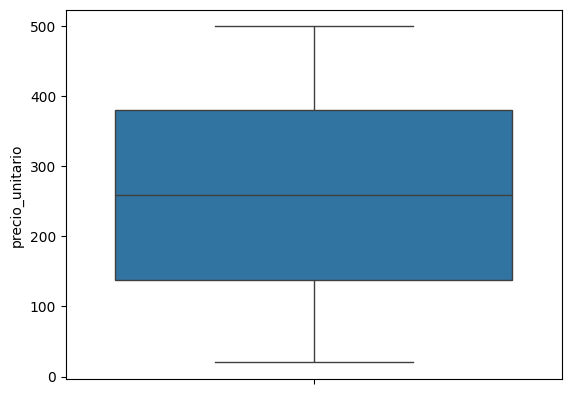


Columna: cantidad

Primer cuartil (Q1): 1.0
Tercer cuartil (Q3): 2.0
Rango intercuartil (IQR): 1.0

Límite inferior (lower_bound): -0.5
Límite superior (upper_bound): 3.5



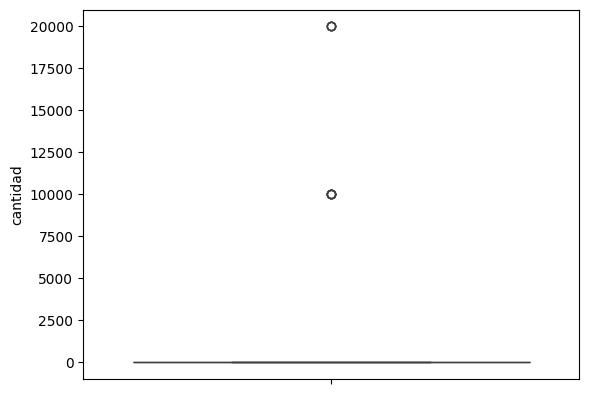


Columna: monto_total

Primer cuartil (Q1): 180.64
Tercer cuartil (Q3): 518.3475
Rango intercuartil (IQR): 337.7075

Límite inferior (lower_bound): -325.92125
Límite superior (upper_bound): 1024.90875



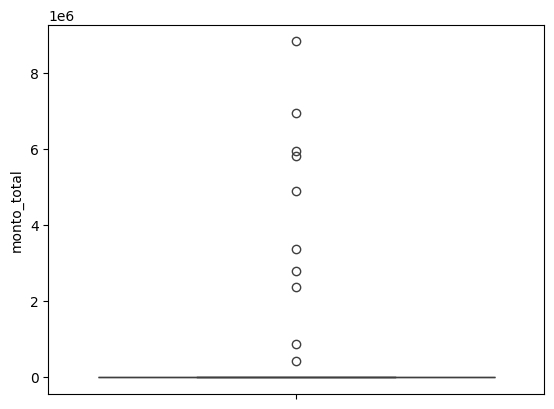

In [34]:
# verificar outliers con IQR
columnas = ['precio_unitario', 'cantidad', 'monto_total']
for col in columnas:
  Q1 = ord[col].quantile(0.25)  # Primer cuartil
  Q2 = ord[col].quantile(0.50)  # Segundo cuartil o mediana
  Q3 = ord[col].quantile(0.75)  # Tercer cuartil
  IQR = Q3 - Q1  # Rango intercuartil
  print("\nColumna:", col)
  print("\nPrimer cuartil (Q1):", Q1)
  print("Tercer cuartil (Q3):", Q3)
  print("Rango intercuartil (IQR):", IQR)

  # Definir umbrales para outliers
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  print("\nLímite inferior (lower_bound):", lower_bound)
  print("Límite superior (upper_bound):", upper_bound)
  print()

  # boxplot
  sns.boxplot(data=ord[col])
  plt.show()

In [35]:
outliers = ord[ord['cantidad'] > upper_bound]
print(f"Total de outliers: {len(outliers)}")
display((outliers[['fecha_hora_pedido', 'nombre_producto', 'pais', 'cantidad', 'monto_total']]).sort_values(
    'fecha_hora_pedido', ascending=False))

Total de outliers: 10


,fecha_hora_pedido,nombre_producto,pais,cantidad,monto_total
3618,2025-06-24,Laptop-Gaming-16GB,Mexico,20000,6966200.0
3639,2025-06-16,Laptop-Gaming-16GB,Mexico,10000,876900.0
3672,2025-05-09,Laptop-Gaming-16GB,Argentina,20000,8840200.0
3472,2025-03-29,Laptop-Gaming-16GB,Argentina,10000,2805500.0
3698,2025-02-23,Laptop-Gaming-16GB,Mexico,10000,3369300.0
3676,2025-02-12,Laptop-Gaming-16GB,Colombia,20000,5817000.0
3471,2025-02-03,Laptop-Gaming-16GB,Mexico,10000,431400.0
3536,2025-02-03,Laptop-Gaming-16GB,Mexico,10000,4903500.0
3593,2025-01-07,Laptop-Gaming-16GB,Colombia,10000,2381500.0
3606,2025-01-01,Laptop-Gaming-16GB,Argentina,20000,5953200.0


In [36]:
print(f"Registros antes de eliminar outliers: {len(ord)}")
# eliminar outliers
ord = ord.drop(outliers.index)
print(f"Registros después de eliminar outliers: {len(ord)}")

Registros antes de eliminar outliers: 24950
Registros después de eliminar outliers: 24940


In [37]:
# cambiar nombre fecha_pedido
ord = ord.rename(columns={'fecha_hora_pedido': 'fecha_pedido'})

In [38]:
# cambiar nombre id_campana
mkt = mkt.rename(columns={'id_campaña': 'id_campana'})

In [39]:
# asociar id_campana a canal
display(mkt.head(10))
print()
display(mkt[mkt[['canal']].isna().any(axis=1)].head(5))

,fecha,pais,id_campana,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40
5,2025-01-01,Colombia,social_Colombia,social,833.38
6,2025-01-01,Argentina,organic_Argentina,organic,1365.62
7,2025-01-01,Argentina,paid_search_Argentina,paid_search,1282.65
8,2025-01-01,Argentina,social_Argentina,social,1534.69
9,2025-01-02,Mexico,organic_Mexico,organic,2537.38


,fecha,pais,id_campana,canal,gasto
98,2025-01-11,Argentina,social_Argentina,NaN,849.70
99,2025-01-12,Mexico,organic_Mexico,NaN,2033.56
100,2025-01-12,Mexico,paid_search_Mexico,NaN,1260.65
101,2025-01-12,Mexico,social_Mexico,NaN,1660.90
102,2025-01-12,Colombia,organic_Colombia,NaN,1819.27


In [40]:
mkt.loc[mkt['canal'].isnull(), 'canal'] = (
    mkt.loc[mkt['canal'].isnull(), 'id_campana'].str.rsplit('_', n = 1).str[0]
)

In [41]:
display(mkt[mkt['canal'].isnull()])
display(mkt.info())

,fecha,pais,id_campana,canal,gasto


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   fecha       1620 non-null   datetime64[ns]
 1   pais        1620 non-null   object        
 2   id_campana  1620 non-null   object        
 3   canal       1620 non-null   object        
 4   gasto       1620 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 63.4+ KB


None

In [42]:
print("Valores nulos en orders?", ord.isnull().values.any())
print("Valores nulos en catalog?", ctl.isnull().values.any())
print("Valores nulos en marketing?", mkt.isnull().values.any())

Valores nulos en orders? False
Valores nulos en catalog? False
Valores nulos en marketing? False


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [43]:
# exportar datasets
ord.to_csv('orders_clean.csv', index=False)
ctl.to_csv('catalog_clean.csv', index=False)
mkt.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

Parte 1: Rentabilidad del negocio

In [44]:
# sumatoria monto_total
ingreso_total = ord['monto_total'].sum()

# costo_unitario de cada producto * cantidad de productos vendidos
costo_dict = ctl.set_index('nombre_producto')['costo_unitario']
costo_total = (
    ord['nombre_producto'].map(costo_dict) * ord['cantidad']).sum()

# sumatoria gasto
marketing_total = mkt['gasto'].sum()

profit = ingreso_total - costo_total - marketing_total
profit_margin = (profit / ingreso_total) * 100
print(f"Revenue Total: ${ingreso_total:,.2f}")
print(f"Costo Total: ${costo_total:,.2f}")
print(f"Inversión Marketing: ${marketing_total:,.2f}")
print(f"Profit: ${profit:,.2f}")
print(f"Margen: {profit_margin:.2f}%")

Revenue Total: $9,623,428.86
Costo Total: $3,828,919.61
Inversión Marketing: $2,871,843.53
Profit: $2,922,665.72
Margen: 30.37%


Parte 2: Comportamiento de ventas

In [45]:
ticket_promedio = (
    ord.groupby('id_pedido')['monto_total'].sum().mean())
print(f"Ticket promedio: ${ticket_promedio:,.2f}")

cantidad_promedio = (
    ord.groupby('id_pedido')['cantidad'].sum().mean())
print(f"Cantidad promedio por orden: {cantidad_promedio:.2f}")

producto_mas_vendido = (
    ord.groupby('nombre_producto')['cantidad'].sum().sort_values(ascending=False))
display(producto_mas_vendido.head(10))
top_producto = producto_mas_vendido.idxmax()
top_unidades = producto_mas_vendido.max()
min_producto = producto_mas_vendido.idxmin()
min_unidades = producto_mas_vendido.min()
print(f"Producto más vendido: {top_producto}")
print(f"Unidades vendidas: {top_unidades}")
print(f"Producto menos vendido: {min_producto}")
print(f"Unidades vendidas: {min_unidades}")

gasto_por_canal = mkt.groupby('canal')['gasto'].sum().sort_values(ascending=False)
print("\nGasto por canal:")
display(gasto_por_canal)

Ticket promedio: $385.86
Cantidad promedio por orden: 1.50


,cantidad
nombre_producto,
Vacuum-Pro-Black,6284
Blender-XL-Red,6279
Jacket-Winter-M,6256
Sneakers-Urban-42,6172
Laptop-Gaming-16GB,4198
Tablet-Standard-64GB,4153
Phone-Pro-128GB,4145
unknown,45


Producto más vendido: Vacuum-Pro-Black
Unidades vendidas: 6284
Producto menos vendido: unknown
Unidades vendidas: 45

Gasto por canal:


,gasto
canal,
social,976818.37
organic,972650.96
paid_search,922374.20


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [46]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [47]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [48]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
GROUP BY 1
ORDER BY 2 DESC;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,add_to_cart,7634
2,select_item,7582
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [50]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
SELECT
COUNT(DISTINCT(CASE WHEN nombre_evento = 'first_visit' THEN id_usuario END)) AS first_visit_user,
100.0 * COUNT(DISTINCT(CASE WHEN nombre_evento = 'add_to_cart' THEN id_usuario END)) / COUNT(DISTINCT(CASE WHEN nombre_evento = 'first_visit' THEN id_usuario END)) AS add_to_cart_retention,
100.0 * COUNT(DISTINCT(CASE WHEN nombre_evento = 'select_item' THEN id_usuario END)) / COUNT(DISTINCT(CASE WHEN nombre_evento = 'first_visit' THEN id_usuario END)) AS select_item_retention,
100.0 * COUNT(DISTINCT(CASE WHEN nombre_evento = 'begin_checkout' THEN id_usuario END)) / COUNT(DISTINCT(CASE WHEN nombre_evento = 'first_visit' THEN id_usuario END)) AS begin_checkout_retention,
100.0 * COUNT(DISTINCT(CASE WHEN nombre_evento = 'add_payment_info' THEN id_usuario END)) / COUNT(DISTINCT(CASE WHEN nombre_evento = 'first_visit' THEN id_usuario END)) AS add_payment_info_retention,
100.0 * COUNT(DISTINCT(CASE WHEN nombre_evento = 'purchase' THEN id_usuario END)) / COUNT(DISTINCT(CASE WHEN nombre_evento = 'first_visit' THEN id_usuario END)) AS purchase_retention

FROM events;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,first_visit_user,add_to_cart_retention,select_item_retention,begin_checkout_retention,add_payment_info_retention,purchase_retention
0,7796,97.922011,97.255003,92.457671,80.169318,80.041047


In [52]:
# Conversión paso a paso
query_conversion = '''
WITH funnel AS (

SELECT
    COUNT(DISTINCT CASE WHEN nombre_evento = 'first_visit'
        THEN id_usuario END) AS first_visit,

    COUNT(DISTINCT CASE WHEN nombre_evento = 'add_to_cart'
        THEN id_usuario END) AS add_to_cart,

    COUNT(DISTINCT CASE WHEN nombre_evento = 'select_item'
        THEN id_usuario END) AS select_item,

    COUNT(DISTINCT CASE WHEN nombre_evento = 'begin_checkout'
        THEN id_usuario END) AS begin_checkout,

    COUNT(DISTINCT CASE WHEN nombre_evento = 'add_payment_info'
        THEN id_usuario END) AS add_payment_info,

    COUNT(DISTINCT CASE WHEN nombre_evento = 'purchase'
        THEN id_usuario END) AS purchase

FROM events

)

SELECT
    ROUND(100.0 * add_to_cart / first_visit,2) AS first_to_cart,
    ROUND(100.0 * select_item / add_to_cart,2) AS cart_to_select,
    ROUND(100.0 * begin_checkout / select_item,2) AS select_to_checkout,
    ROUND(100.0 * add_payment_info / begin_checkout,2) AS checkout_to_payment,
    ROUND(100.0 * purchase / add_payment_info,2) AS payment_to_purchase,
    ROUND(100.0 * purchase / first_visit,2) AS final_conversion
FROM funnel;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,first_to_cart,cart_to_select,select_to_checkout,checkout_to_payment,payment_to_purchase,final_conversion
0,97.92,99.32,95.07,86.71,99.84,80.04


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [53]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [54]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [ ]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
tu código SQL aquí
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):** ...
   - **H₁ (Hipótesis alternativa):** ...
   
**Test estadístico:** ...  
**Nivel de significancia alpha:** ...

In [ ]:
# tu código aquí



---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

In [ ]:
# (Pega aquí tu link)
# link de power bi o tableau
# link de one drive / google drive